<a href="https://colab.research.google.com/github/angelagdca/GDP_first_model/blob/main/GDP_model_second_try.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PIB España (BISTRO)**

In [ ]:
#Solo 1 vez para no romper el entorno
!pip uninstall -y numpy pandas scipy gluonts uni2ts
!pip install --no-cache-dir --force-reinstall \
    numpy==1.26.4 \
    pandas==2.1.4 \
    scipy==1.11.4
!pip install --no-cache-dir gluonts
!pip install --no-cache-dir uni2ts

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 2.1.4
Uninstalling pandas-2.1.4:
  Successfully uninstalled pandas-2.1.4
Found existing installation: scipy 1.11.4
Uninstalling scipy-1.11.4:
  Successfully uninstalled scipy-1.11.4
Found existing installation: gluonts 0.14.4
Uninstalling gluonts-0.14.4:
  Successfully uninstalled gluonts-0.14.4
Found existing installation: uni2ts 1.1.1
Uninstalling uni2ts-1.1.1:
  Successfully uninstalled uni2ts-1.1.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 365.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 520.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 306.9 MB/s  0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found existing installation: tzdata 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 113.0 MB/s  0:00:00
ERROR: Operation cancelled by user
^C


###**Step 1**

Preparar el entorno y las librerías necesarias para ejecutar BISTRO/Moirai.

In [ ]:
#Deja listo el entorno para usar BISTRO/Moirai

import os
import sys
import subprocess
from pathlib import Path

#Compatibilidad de NumPy (sobre todo en Google Colab)
try:
    import numpy as np

    if np.__version__.startswith("2."):
        print(f"Current NumPy is {np.__version__}. Downgrading to 1.26.4...")

        subprocess.run([
            "pip", "install", "-q", "--force-reinstall",
            "numpy==1.26.4",
            "pandas==2.1.4",
            "scipy==1.11.4",
            "opencv-python==4.8.0.76"
        ], check=True)

        print("✅ Install complete. Restarting runtime automatically...")
        os.kill(os.getpid(), 9)

    else:
        print(f"✅ Success! Using NumPy version: {np.__version__}")

except Exception as e:
    print(f"NumPy compatibility check skipped/error: {e}")

#Si estás en Google Colab: clonar repo e instalar deps

if 'google.colab' in sys.modules:
    print("Running in Google Colab. Cloning BISTRO repo...")

    if not os.path.exists("/content/bistro"):
        !git clone -q https://github.com/bis-med-it/bistro.git

    print("Installing project dependencies...")
    !pip install -q -r /content/bistro/requirements.txt

    print("✅ Repository and dependencies ready.")

✅ Success! Using NumPy version: 1.26.4
Running in Google Colab. Cloning BISTRO repo...
Installing project dependencies...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
pointpats 2.5.5 requires pandas>=2.2, but you have pandas 2.1.4 which is incompatible.
pointpats 2.5.5 requires scipy>=1.12, but you have scipy 1.11.4 which is incompatible.
mizani 0.13.5 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydantic 2.12.5 which is incompatible.
giddy 2.3.8 requires scipy>=1.12, but you have scipy 1.11.4 which is inco

In [ ]:
#Ajustar rutas del proyecto

if 'google.colab' in sys.modules:
    project_root = Path("/content/bistro")
else:
    # Cambia esta ruta si trabajas en local
    project_root = Path.cwd()

repo_root = project_root
src_root = repo_root / "src"
script_root = repo_root / "script"

if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

if str(script_root) not in sys.path:
    sys.path.insert(0, str(script_root))

print("repo_root:", repo_root)
print("src_root:", src_root)
print("script_root:", script_root)

#Imports principales
import numpy as np
import pandas as pd

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

from inference_util import plot_publication_forecast_comparison
from preprocessing_util import (
    aggregate_daily_forecast_to_monthly,
    prepare_yoy_monthly_for_daily_inference,
)

print("✅ Core imports loaded successfully.")

repo_root: /content/bistro
src_root: /content/bistro/src
script_root: /content/bistro/script
✅ Core imports loaded successfully.


###**Step 2**

In [ ]:
import requests
import numpy as np
import pandas as pd

In [ ]:

def load_spain_gdp_from_eurostat():
    # Dataset oficial de Eurostat:
    # namq_10_gdp = quarterly GDP and main components
    # Filtros elegidos:
    # geo=ES              -> España
    # na_item=B1GQ        -> GDP
    # unit=CLV10_MNAC     -> volumen encadenado, millones moneda nacional
    # s_adj=SCA           -> seasonally and calendar adjusted
    # freq=Q              -> quarterly
    url = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/namq_10_gdp"
    params = {
        "lang": "EN",
        "geo": "ES",
        "na_item": "B1GQ",
        "unit": "CLV10_MNAC",
        "s_adj": "SCA",
        "freq": "Q",
    }

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    js = r.json()

    # Localiza la dimensión tiempo
    time_key = next(k for k in js["dimension"].keys() if k.lower().startswith("time"))

    # Orden correcto de los periodos
    time_index = js["dimension"][time_key]["category"]["index"]
    if isinstance(time_index, dict):
        times = [k for k, _ in sorted(time_index.items(), key=lambda x: x[1])]
    else:
        # fallback raro, por si viniera en otro formato
        time_labels = js["dimension"][time_key]["category"]["label"]
        times = list(time_labels.keys())

    # Valores: a veces vienen como lista y a veces como dict disperso
    values_raw = js["value"]
    if isinstance(values_raw, dict):
        values = [values_raw.get(str(i), np.nan) for i in range(len(times))]
    else:
        values = list(values_raw)

    df = pd.DataFrame({
        "date": times,
        "spain_real_gdp": values,
    })

    df["spain_real_gdp"] = pd.to_numeric(df["spain_real_gdp"], errors="coerce")
    df["date"] = pd.PeriodIndex(df["date"], freq="Q")
    df = (
        df.dropna(subset=["spain_real_gdp"])
          .drop_duplicates(subset=["date"], keep="last")
          .set_index("date")
          .sort_index()
    )

    return df

# Serie actualizada
df = load_spain_gdp_from_eurostat()
target_col = df.columns[0]

# Opcional: guardar una copia CSV actualizada automáticamente
csv_path = "spain_gdp_latest.csv"
df.to_csv(csv_path)

print("Últimos datos descargados:")
display(df.tail())
print(f"CSV actualizado guardado en: {csv_path}")

Últimos datos descargados:


,spain_real_gdp
date,
2024Q4,324467.2
2025Q1,326054.0
2025Q2,328474.4
2025Q3,330587.9
2025Q4,333321.7


CSV actualizado guardado en: spain_gdp_latest.csv


Limpiamos y preparamos la serie de PIB

In [ ]:
# Serie actualizada desde Eurostat
df = load_spain_gdp_from_eurostat().copy()

# Renombrar columna a un nombre más cómodo
df = df.rename(columns={"spain_real_gdp": "gdp_real"})

# La función ya devuelve índice trimestral PeriodIndex, así que no hace falta convertir fechas otra vez
FREQ = "Q"

# Crear crecimiento trimestral del PIB en %
df["gdp_qoq"] = df["gdp_real"].pct_change() * 100

# Serie objetivo
target_col = "gdp_qoq"
df_target = df[[target_col]].dropna().copy()

# Comprobaciones
print("Número de observaciones:", len(df_target))
print()
print(df_target.head())
print()
print(df_target.tail())

print(df[["gdp_real", "gdp_qoq"]].head(10))
df_target

Número de observaciones: 123

         gdp_qoq
date            
1995Q2  0.659168
1995Q3  0.442631
1995Q4  0.757027
1996Q1  0.574896
1996Q2  0.691353

         gdp_qoq
date            
2024Q4  0.813581
2025Q1  0.489048
2025Q2  0.742331
2025Q3  0.643429
2025Q4  0.826951
        gdp_real   gdp_qoq
date                      
1995Q1  178588.8       NaN
1995Q2  179766.0  0.659168
1995Q3  180561.7  0.442631
1995Q4  181928.6  0.757027
1996Q1  182974.5  0.574896
1996Q2  184239.5  0.691353
1996Q3  185750.8  0.820291
1996Q4  186674.9  0.497494
1997Q1  188536.4  0.997188
1997Q2  190237.4  0.902213


,gdp_qoq
date,
1995Q2,0.659168
1995Q3,0.442631
1995Q4,0.757027
1996Q1,0.574896
1996Q2,0.691353
...,...
2024Q4,0.813581
2025Q1,0.489048
2025Q2,0.742331


###**Step 3**

Definir la estructura del forecast: horizonte, ventana histórica y división entre train y test.

- Horizonte de forecast
- Longitud de contexto
- Serie objetivo en el formato correcto
- Punto desde el que queremos predecir

Frequency: Q
Prediction length: 4
Context length: 80

Serie objetivo:
date
1995Q2    0.659168
1995Q3    0.442631
1995Q4    0.757027
1996Q1    0.574896
1996Q2    0.691353
Freq: Q-DEC, Name: gdp_qoq, dtype: float64
date
2024Q4    0.813581
2025Q1    0.489048
2025Q2    0.742331
2025Q3    0.643429
2025Q4    0.826951
Freq: Q-DEC, Name: gdp_qoq, dtype: float64

Último dato observado: 2025Q4
Forecast empieza en: 2026Q1


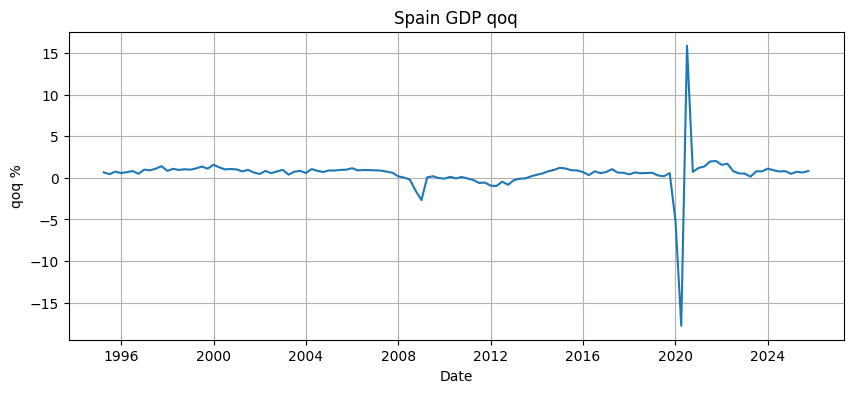

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Parámetros del forecast
FREQ = "Q"
PDT = 4   # 4 trimestres
CTX = 80  # 80 trimestres de contexto
BSZ = 32
PSZ = 32

print("Frequency:", FREQ)
print("Prediction length:", PDT)
print("Context length:", CTX)

# Serie objetivo final
ts = df_target[target_col].copy()

print()
print("Serie objetivo:")
print(ts.head())
print(ts.tail())

# Forecast para 2026
forecast_start = pd.Period("2026Q1", freq=FREQ)

print()
print("Último dato observado:", ts.index[-1])
print("Forecast empieza en:", forecast_start)

# Visualización rápida de la serie
plt.figure(figsize=(10, 4))
plt.plot(ts.index.to_timestamp(), ts.values)
plt.title("Spain GDP qoq")
plt.xlabel("Date")
plt.ylabel("qoq %")
plt.grid(True)
plt.show()

Convertimos la serie trimestral a un dataframe compatible con el pipeline de forecasting

In [ ]:
!pip install gluonts
from gluonts.dataset.pandas import PandasDataset

In [ ]:
FORECAST_START_DATE = "2026Q1"
ROLLING_WINDOWS = 1
WINDOW_DISTANCE = 1

prep = prepare_yoy_monthly_for_daily_inference(
    df_target,
    target_col=target_col,
    freq=FREQ,
    forecast_start_date=FORECAST_START_DATE,
    pdt_patches=PDT,
    ctx_patches=CTX,
    steps_per_period=PSZ,
    rolling_windows=ROLLING_WINDOWS,
    window_distance_patches=WINDOW_DISTANCE,
)

last_actual_period = prep.df_monthly.index.max()
pure_future_forecast = prep.forecast_start > last_actual_period
forecast_windows = 1 if pure_future_forecast else prep.windows

ds = PandasDataset(prep.daily_df, target=target_col)
train, test_template = split(ds, date=prep.cutoff_period_daily)

test_data = test_template.generate_instances(
    prediction_length=prep.pdt_steps,
    windows=forecast_windows,
    distance=prep.dist_steps,
    max_history=prep.ctx_steps,
)

###**Step 4**

Ejecutar la predicción con BISTRO sobre el PIB de España y comparar el forecast con los datos reales.

In [ ]:
import os
from pathlib import Path

if not Path("/content/bistro").exists():
    !git clone -q https://github.com/bis-med-it/bistro.git /content/bistro

!pip install -q -r /content/bistro/requirements.txt

In [ ]:
import os
import sys
from pathlib import Path

os.chdir("/content/bistro/script")

repo_root_bistro = Path("..").resolve()
src_root = Path("../src").resolve()

if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print("repo_root_bistro:", repo_root_bistro)
print("src_root:", src_root)

repo_root_bistro: /content/bistro
src_root: /content/bistro/src


In [ ]:
#IMPORTS

import numpy as np
import pandas as pd

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

In [ ]:
#Preparar la serie para inferencia futura con BISTRO

MODEL_REPO = repo_root / "bistro-finetuned"

ROLLING_WINDOWS = 1
WINDOW_DISTANCE = 1
FORECAST_START_DATE = "2026Q1"

config = {
    "MODEL_REPO": str(MODEL_REPO),
    "PDT": PDT,
    "CTX": CTX,
    "PSZ": PSZ,
    "BSZ": BSZ,
    "ROLLING_WINDOWS": ROLLING_WINDOWS,
    "WINDOW_DISTANCE": WINDOW_DISTANCE,
    "FORECAST_START_DATE": FORECAST_START_DATE,
    "NUM_SAMPLES": 100,
}

#Preparación de la serie para inferencia
prep = prepare_yoy_monthly_for_daily_inference(
    df_target,
    target_col=target_col,
    freq=FREQ,
    forecast_start_date=FORECAST_START_DATE,
    pdt_patches=PDT,
    ctx_patches=CTX,
    steps_per_period=PSZ,
    rolling_windows=ROLLING_WINDOWS,
    window_distance_patches=WINDOW_DISTANCE,
)

#Detectar si estamos forecastando fuera de muestra
last_actual_period = prep.df_monthly.index.max()
pure_future_forecast = prep.forecast_start > last_actual_period

#En forecast futuro puro, forzamos 1 ventana aunque prep.windows salga 0
forecast_windows = 1 if pure_future_forecast else prep.windows

# Solo lanzar error si esto fuera backtest y no hubiera ventanas suficientes
if (not pure_future_forecast) and (prep.windows < 1):
    raise ValueError(
        f"Not enough test data after cutoff {prep.train_end} to create a window: "
        f"test_len={(prep.df_yoy_dt.index > prep.cutoff_date_dt).sum()} periods, PDT={PDT}."
    )

#Dataset que usará realmente BISTRO
ds = PandasDataset(prep.daily_df, target=target_col)

#Split interno de GluonTS para generar la instancia de forecast
train, test_template = split(ds, date=prep.cutoff_period_daily)

test_data = test_template.generate_instances(
    prediction_length=prep.pdt_steps,
    windows=forecast_windows,
    distance=prep.dist_steps,
    max_history=prep.ctx_steps,
)

print("Último dato observado:", last_actual_period)
print("Forecast start:", prep.forecast_start)
print("Pure future forecast:", pure_future_forecast)
print("Número de ventanas:", forecast_windows)
print("Prediction length interna:", prep.pdt_steps)
print("Context length interna:", prep.ctx_steps)

Último dato observado: 2025Q4
Forecast start: 2026Q1
Pure future forecast: True
Número de ventanas: 1
Prediction length interna: 128
Context length interna: 2560


In [ ]:
import numpy as np
import pandas as pd

from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

In [ ]:
#Ejecutamos el bistro
from pathlib import Path

MODEL_REPO = Path("/content/bistro/bistro-finetuned")

model = MoiraiForecast(
    module = MoiraiModule.from_pretrained(str(MODEL_REPO)),
    prediction_length = int(prep.pdt_steps),
    context_length = int(prep.ctx_steps),
    patch_size = int(PSZ),
    num_samples = 100,
    target_dim = 1,
    feat_dynamic_real_dim = 0,
    past_feat_dynamic_real_dim = 0,
)

predictor = model.create_predictor(batch_size=BSZ)

inputs = list(test_data.input)
labels = list(test_data.label)
forecasts = list(predictor.predict(test_data.input))

print("Número de forecasts generados:", len(forecasts))

Loading weights from local directory
Número de forecasts generados: 1


In [ ]:
#Reconstruir forecast trimestral y tabla final

bistro_forecast_by_window = {}
rmse_rows = []

for w in range(forecast_windows):
    samples = np.asarray(forecasts[w].samples, dtype=float)

    # En forecast puro futuro, labels puede venir vacío o sin target útil
    if w < len(labels) and isinstance(labels[w], dict) and "target" in labels[w]:
        label_target = np.asarray(labels[w]["target"], dtype=float)
    else:
        label_target = np.asarray([], dtype=float)

    if w < len(inputs) and isinstance(inputs[w], dict) and "target" in inputs[w]:
        inp_target = np.asarray(inputs[w]["target"], dtype=float)
    else:
        inp_target = np.asarray([], dtype=float)

    last_input = float(inp_target[-1]) if inp_target.size > 0 else None

    preds, _, ci = aggregate_daily_forecast_to_monthly(
        samples,
        label_target,
        last_input,
        steps_per_period=PSZ,
        expected_periods=PDT,
    )

    pred_index = pd.period_range(
        start=prep.forecast_start + w * WINDOW_DISTANCE,
        periods=PDT,
        freq=FREQ,
    )

    dfw = pd.DataFrame(
        {
            "bistro_pred": preds,
            "bistro_lo": ci[:, 0],
            "bistro_hi": ci[:, 1],
        },
        index=pred_index,
    )

    bistro_forecast_by_window[w] = dfw

    actual = prep.df_monthly[target_col].reindex(pred_index).astype(float)

    # Como estás forecastando 2026, no habrá actuals todavía
    if pure_future_forecast:
        actual[:] = np.nan

    pred = dfw["bistro_pred"].astype(float)
    valid = actual.notna() & pred.notna()
    rmse = float(np.sqrt(np.mean((pred[valid] - actual[valid]) ** 2))) if valid.any() else np.nan

    rmse_rows.append(
        {
            "window": w,
            "forecast_start": pred_index[0],
            "forecast_end": pred_index[-1],
            "rmse": rmse,
            "n_valid": int(valid.sum()),
        }
    )

rmse_table = pd.DataFrame(rmse_rows)

print("Resumen de ventanas:")
display(rmse_table)

forecast_2026 = bistro_forecast_by_window[0].copy()
forecast_2026 = forecast_2026.loc["2026Q1":"2026Q4"]

print("Forecast QoQ de España para 2026:")
display(forecast_2026)

Resumen de ventanas:


,window,forecast_start,forecast_end,rmse,n_valid
0,0,2026Q1,2026Q4,NaN,0


Forecast QoQ de España para 2026:


,bistro_pred,bistro_lo,bistro_hi
2026Q1,0.717216,0.489357,1.048685
2026Q2,0.665714,0.368010,1.208697
2026Q3,0.712318,0.360383,1.342401
2026Q4,0.580337,0.149830,2.329615


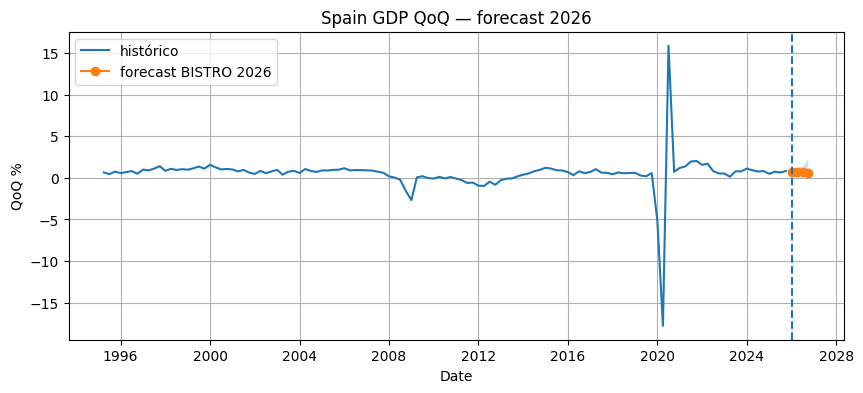

In [ ]:
#Gráfico del forecast 2026

import matplotlib.pyplot as plt
import pandas as pd

hist = prep.df_monthly[target_col].copy()

plt.figure(figsize=(10, 4))

# Histórico
plt.plot(
    hist.index.to_timestamp(),
    hist.values,
    label="histórico"
)


# Forecast 2026
plt.plot(
    forecast_2026.index.to_timestamp(),
    forecast_2026["bistro_pred"].values,
    marker="o",
    label="forecast BISTRO 2026"
)

# Bandas
plt.fill_between(
    forecast_2026.index.to_timestamp(),
    forecast_2026["bistro_lo"].values,
    forecast_2026["bistro_hi"].values,
    alpha=0.2
)

# Línea vertical donde empieza el forecast
plt.axvline(pd.Period("2026Q1", freq="Q").to_timestamp(), linestyle="--")
plt.title("Spain GDP QoQ — forecast 2026")
plt.xlabel("Date")
plt.ylabel("QoQ %")
plt.grid(True)
plt.legend()
plt.show()

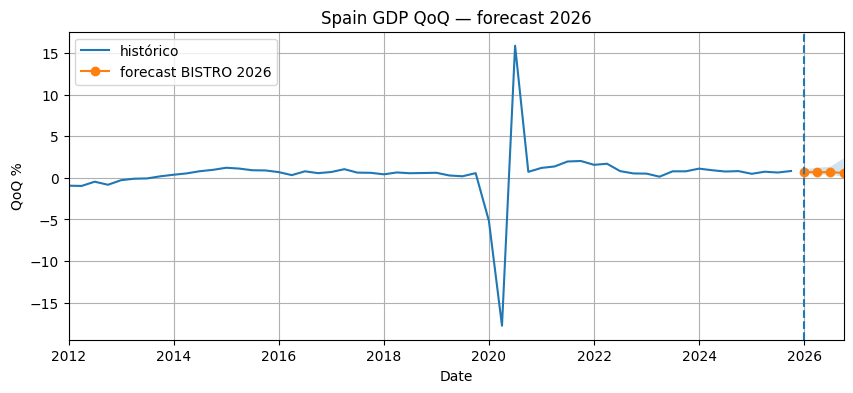

In [ ]:
#Gráfico del forecast 2026

import matplotlib.pyplot as plt
import pandas as pd

hist = prep.df_monthly[target_col].copy()

# Empezar el gráfico en 2012Q1
plot_start = pd.Period("2012Q1", freq="Q")

# Filtrar histórico desde 2012
hist_plot = hist.loc[hist.index >= plot_start].copy()

plt.figure(figsize=(10, 4))

# Histórico
plt.plot(
    hist_plot.index.to_timestamp(),
    hist_plot.values,
    label="histórico"
)

# Forecast 2026
plt.plot(
    forecast_2026.index.to_timestamp(),
    forecast_2026["bistro_pred"].values,
    marker="o",
    label="forecast BISTRO 2026"
)

# Bandas
plt.fill_between(
    forecast_2026.index.to_timestamp(),
    forecast_2026["bistro_lo"].values,
    forecast_2026["bistro_hi"].values,
    alpha=0.2
)

# Línea vertical donde empieza el forecast
plt.axvline(pd.Period("2026Q1", freq="Q").to_timestamp(), linestyle="--")

plt.title("Spain GDP QoQ — forecast 2026")
plt.xlabel("Date")
plt.ylabel("QoQ %")
plt.grid(True)
plt.legend()
plt.xlim(plot_start.to_timestamp(), forecast_2026.index[-1].to_timestamp())
plt.show()

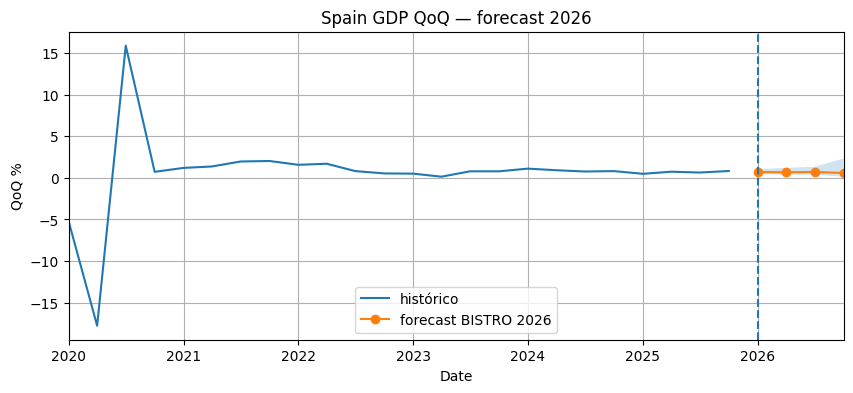

In [ ]:
#Gráfico del forecast 2026

import matplotlib.pyplot as plt
import pandas as pd

hist = prep.df_monthly[target_col].copy()

# Empezar el gráfico en 2012Q1
plot_start = pd.Period("2020Q1", freq="Q")

# Filtrar histórico desde 2012
hist_plot = hist.loc[hist.index >= plot_start].copy()

plt.figure(figsize=(10, 4))

# Histórico
plt.plot(
    hist_plot.index.to_timestamp(),
    hist_plot.values,
    label="histórico"
)

# Forecast 2026
plt.plot(
    forecast_2026.index.to_timestamp(),
    forecast_2026["bistro_pred"].values,
    marker="o",
    label="forecast BISTRO 2026"
)

# Bandas
plt.fill_between(
    forecast_2026.index.to_timestamp(),
    forecast_2026["bistro_lo"].values,
    forecast_2026["bistro_hi"].values,
    alpha=0.2
)

# Línea vertical donde empieza el forecast
plt.axvline(pd.Period("2026Q1", freq="Q").to_timestamp(), linestyle="--")

plt.title("Spain GDP QoQ — forecast 2026")
plt.xlabel("Date")
plt.ylabel("QoQ %")
plt.grid(True)
plt.legend()
plt.xlim(plot_start.to_timestamp(), forecast_2026.index[-1].to_timestamp())
plt.show()